# Feature Engineering — adapted for `matchups.csv` (T1/T2 wide format)  ·  v3 with advanced features

Same structure as your existing `build_features_nba.ipynb`, with all the high-impact features that are computable from `matchups.csv` added inline.

### Pipeline

1. **Setup** — config and load
2. **Step 0** — Reshape T1/T2 wide → team-perspective long *(unchanged)*
3. **Step 0.5 (NEW)** — Four Factors, Pace, Power Rating, Altitude
4. **Step 1 (extended)** — Per-team chronological features  *(adds `Is_3in4`, `Is_4in5`, `Form_Gap_5`, `Form_Gap_10`)*
5. **Step 2 (extended)** — Self-join + diffs *(picks up the new per-team features)*
6. **Step 3** — Head-to-head *(unchanged)*
7. **Step 4** — Elo-implied win probability *(unchanged)*
8. **Step 5** — Save `matchups_v2.csv`
9. **Sanity checks** *(extended)*

### What's new

**Four Factors (Dean Oliver) — offense, defense, and diff for each:**
- `eFG_Pct`, `Def_eFG_Pct` — effective field goal % (3pt-weighted)
- `TS_Pct`, `Def_TS_Pct` — true shooting %
- `OR_Rate`, `DR_Rate` — rebound % (rates, not raw counts)
- `TO_Rate`, `Def_TO_Rate` — turnovers per possession
- `FT_Rate`, `Def_FT_Rate` — `FTA / FGA`

**Pace and possessions** — `Poss = FGA - OR + TO + 0.475 * FTA` from both sides; `Pace` is per-team possessions/game.

**Composite Power Rating** — `Net_Rating + 0.04 * (Elo - 1500)`. Combines two correlated signals into one stronger feature; helps shallow trees.

**Schedule density** — `Is_3in4`, `Is_4in5` extending the `Is_B2B` family.

**Recent-form gap** — `Form_Gap_N = LastN_Win_Pct − season Win_Pct`. Captures hot/cold streaks relative to baseline.

**Altitude disadvantage** — `Team_Altitude_Dis` / `Opp_Altitude_Dis` flags for road games at Denver or Utah.

### Skipped (would require upstream changes)

- **`NetEff_std` / volatility** — needs per-game stats; your `matchups.csv` only has season averages.
- **Trimmed means** — same reason. To add these, modify the dataset builder that produces `matchups.csv` to compute them at aggregation time.
- **OT normalization** — same reason. Your aggregates are already baked, so OT inflation (if any) is also already baked in.

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

# ---- Config ----
INPUT_CSV    = "matchups.csv"
OUTPUT_CSV   = "matchups_v2.csv"
ELO_HOME_ADV = 100.0    # match the constant your dataset builder used
T1_IS_HOME   = True     # T1 win rate ~0.562 ≈ NBA home win rate, so T1 = home
ELO_TO_NETRATING = 0.04 # 100 Elo gap ≈ 4 net-rating points (logistic Elo ≈ 3.5; 0.04 is close)
ALTITUDE_TEAM_IDS = {1610612743, 1610612762}  # Nuggets (Denver), Jazz (Salt Lake City)
OUT_DIR      = Path(".")
# ----------------

wide = pd.read_csv(INPUT_CSV, parse_dates=['DayDate'])
print(f"{INPUT_CSV}: {wide.shape}")
print(f"Seasons: {sorted(wide['Season'].unique())}")
print(f"T1 win rate: {wide['Target_Win'].mean():.3f}  (≈ NBA home-court rate ~ 0.56–0.58)")

matchups.csv: (11969, 83)
Seasons: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
T1 win rate: 0.562  (≈ NBA home-court rate ~ 0.56–0.58)


## Step 0 — Reshape T1/T2 wide → team-perspective long

*(Unchanged from v2.)* Each row becomes two rows; computes `Diff_<stat> = team_<stat> − opp_<stat>` for every paired numeric column.

In [2]:
def wide_to_team_perspective(wide: pd.DataFrame, t1_is_home: bool = True) -> pd.DataFrame:
    t1_cols = [c for c in wide.columns if c.startswith('T1_')]
    t2_cols = [c for c in wide.columns if c.startswith('T2_')]
    t1_stats = {c[len('T1_'):] for c in t1_cols}
    t2_stats = {c[len('T2_'):] for c in t2_cols}
    paired_stats = sorted(t1_stats & t2_stats)
    only_t1 = sorted(t1_stats - t2_stats)
    only_t2 = sorted(t2_stats - t1_stats)
    if only_t1 or only_t2:
        print(f"  warning: unpaired columns -- T1 only: {only_t1} | T2 only: {only_t2}")

    shared_cols = [c for c in wide.columns
                   if not c.startswith('T1_') and not c.startswith('T2_') and c != 'Target_Win']

    def build_view(team_prefix: str, opp_prefix: str, target_win: pd.Series, is_home: int) -> pd.DataFrame:
        rename = {}
        for s in paired_stats:
            rename[f'{team_prefix}{s}'] = f'team_{s}'
            rename[f'{opp_prefix}{s}']  = f'opp_{s}'
        view = wide.rename(columns=rename)[shared_cols
                                          + [f'team_{s}' for s in paired_stats]
                                          + [f'opp_{s}'  for s in paired_stats]].copy()
        view['Target_Win'] = target_win.values
        view['Is_Home']    = is_home
        return view

    t1_view = build_view('T1_', 'T2_', wide['Target_Win'],     int(t1_is_home))
    t2_view = build_view('T2_', 'T1_', 1 - wide['Target_Win'], int(not t1_is_home))

    long = pd.concat([t1_view, t2_view], ignore_index=True)
    long = long.rename(columns={'team_TeamID': 'TeamID', 'opp_TeamID': 'OppID'})

    for s in paired_stats:
        if s == 'TeamID':
            continue
        team_c, opp_c = f'team_{s}', f'opp_{s}'
        if pd.api.types.is_numeric_dtype(long[team_c]) and pd.api.types.is_numeric_dtype(long[opp_c]):
            long[f'Diff_{s}'] = long[team_c] - long[opp_c]

    return long


mm = wide_to_team_perspective(wide, t1_is_home=T1_IS_HOME)
print(f"Reshaped: {wide.shape} -> {mm.shape}  (rows doubled: {len(mm) == 2*len(wide)})")

Reshaped: (11969, 83) -> (23938, 122)  (rows doubled: True)


## Step 0.5 (NEW) — Four Factors, Pace, Power Rating, Altitude

Compute per-possession and rate-based features from the season aggregates that came through the reshape. These are computed **per perspective** (team and opp) and then differenced.

**Possession formula** (Dean Oliver): `Poss = FGA − OR + TO + 0.475 × FTA`. We compute it from both each team's own offense (`team_Avg_FGA`, …) and what their opponents did against them (`team_Avg_Opp_FGA`, …). Pace is the average of the two.

**Why rates over counts:** a team that plays at 102 possessions/game vs one that plays at 95 will have inflated counting stats. Rates (eFG%, TO/poss, OR%, FT/FGA) strip pace out and isolate efficiency.

In [3]:
def add_four_factors_and_pace(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    def poss_off(prefix):  # offensive possessions (this side scoring)
        return (df[f'{prefix}Avg_FGA'] - df[f'{prefix}Avg_OR']
                + df[f'{prefix}Avg_TO'] + 0.475 * df[f'{prefix}Avg_FTA'])
    def poss_def(prefix):  # defensive possessions (opp scoring on this side)
        return (df[f'{prefix}Avg_Opp_FGA'] - df[f'{prefix}Avg_Opp_OR']
                + df[f'{prefix}Avg_Opp_TO'] + 0.475 * df[f'{prefix}Avg_Opp_FTA'])

    for side in ['team', 'opp']:
        off_p = poss_off(f'{side}_')
        def_p = poss_def(f'{side}_')

        # Pace: per-team possessions per game (avg of off and def — they should be ~equal)
        df[f'{side}_Pace'] = (off_p + def_p) / 2

        # ---- Offensive Four Factors ----
        df[f'{side}_eFG_Pct'] = ((df[f'{side}_Avg_FGM'] + 0.5 * df[f'{side}_Avg_FGM3'])
                                 / df[f'{side}_Avg_FGA'])
        df[f'{side}_TS_Pct'] = (df[f'{side}_Avg_Score']
                                / (2 * (df[f'{side}_Avg_FGA'] + 0.475 * df[f'{side}_Avg_FTA'])))
        df[f'{side}_OR_Rate'] = (df[f'{side}_Avg_OR']
                                  / (df[f'{side}_Avg_OR'] + df[f'{side}_Avg_Opp_DR']))
        df[f'{side}_TO_Rate'] = df[f'{side}_Avg_TO'] / off_p
        df[f'{side}_FT_Rate'] = df[f'{side}_Avg_FTA'] / df[f'{side}_Avg_FGA']

        # ---- Defensive Four Factors (what opponents do against this side) ----
        df[f'{side}_Def_eFG_Pct'] = ((df[f'{side}_Avg_Opp_FGM'] + 0.5 * df[f'{side}_Avg_Opp_FGM3'])
                                       / df[f'{side}_Avg_Opp_FGA'])
        df[f'{side}_Def_TS_Pct'] = (df[f'{side}_Avg_Opp_Score']
                                      / (2 * (df[f'{side}_Avg_Opp_FGA']
                                              + 0.475 * df[f'{side}_Avg_Opp_FTA'])))
        df[f'{side}_DR_Rate'] = (df[f'{side}_Avg_DR']
                                  / (df[f'{side}_Avg_DR'] + df[f'{side}_Avg_Opp_OR']))
        df[f'{side}_Def_TO_Rate'] = df[f'{side}_Avg_Opp_TO'] / def_p
        df[f'{side}_Def_FT_Rate'] = df[f'{side}_Avg_Opp_FTA'] / df[f'{side}_Avg_Opp_FGA']

    # ---- Composite power rating: Net Rating + Elo blend ----
    for side in ['team', 'opp']:
        df[f'{side}_Power_Rating'] = (df[f'{side}_Net_Rating']
                                       + ELO_TO_NETRATING * (df[f'{side}_Pregame_Elo'] - 1500))

    # ---- Diff_* for every new feature ----
    new_paired = ['Pace',
                  'eFG_Pct', 'TS_Pct', 'OR_Rate', 'TO_Rate', 'FT_Rate',
                  'Def_eFG_Pct', 'Def_TS_Pct', 'DR_Rate', 'Def_TO_Rate', 'Def_FT_Rate',
                  'Power_Rating']
    for c in new_paired:
        df[f'Diff_{c}'] = df[f'team_{c}'] - df[f'opp_{c}']

    return df


def add_altitude_flags(df: pd.DataFrame, altitude_ids: set) -> pd.DataFrame:
    df = df.copy()
    # This team is at altitude disadvantage iff: this team is the road team AND opp is at altitude.
    df['Team_Altitude_Dis'] = ((df['Is_Home'] == 0) & df['OppID'].isin(altitude_ids)).astype('Int8')
    # Opp is at altitude disadvantage iff: this team is at home AND this team is at altitude.
    df['Opp_Altitude_Dis']  = ((df['Is_Home'] == 1) & df['TeamID'].isin(altitude_ids)).astype('Int8')
    return df


mm = add_four_factors_and_pace(mm)
mm = add_altitude_flags(mm, ALTITUDE_TEAM_IDS)

print("Sanity-peek at new features:")
summary_cols = ['team_Pace', 'team_eFG_Pct', 'team_TS_Pct', 'team_OR_Rate',
                'team_TO_Rate', 'team_FT_Rate', 'team_Power_Rating',
                'Diff_Pace', 'Diff_eFG_Pct', 'Diff_Power_Rating',
                'Team_Altitude_Dis', 'Opp_Altitude_Dis']
print(mm[summary_cols].describe().T[['mean', 'std', 'min', 'max']].round(4))

Sanity-peek at new features:
                         mean        std        min        max
team_Pace          103.036966   2.810465       92.2    130.375
team_eFG_Pct         0.529711   0.025351   0.345361   0.666667
team_TS_Pct          0.560914    0.02401   0.386226   0.684705
team_OR_Rate         0.236191   0.031493   0.073171     0.4375
team_TO_Rate         0.140766     0.0132   0.043573   0.252366
team_FT_Rate         0.259086   0.032501   0.084211      0.575
team_Power_Rating    0.053698   9.433033 -48.916572  45.796416
Diff_Pace                 0.0   3.393132   -29.6375    29.6375
Diff_eFG_Pct              0.0   0.031421  -0.235206   0.235206
Diff_Power_Rating        -0.0  13.443213 -52.929416  52.929416
Team_Altitude_Dis     0.03342   0.179734        0.0        1.0
Opp_Altitude_Dis      0.03342   0.179734        0.0        1.0


## Step 1 (extended) — Per-team chronological features

Original features (`Days_Rest`, `Is_B2B`, `Win_Streak`, `Last5/10_Win_Pct`) plus three new ones:

- **`Is_3in4`** — third game in four nights. Looks back at game `t-2` and checks if it was within 3 days. NBA scheduling pain-point.
- **`Is_4in5`** — fourth game in five nights. Even rarer / more grueling.
- **`Form_Gap_N`** — `LastN_Win_Pct − team_Win_Pct`. A team running hot above its season baseline scores positive; a team slumping scores negative.

All use `shift(N)` within each `(TeamID, Season)` group so the current game's outcome never leaks.

In [4]:
def add_per_team_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['TeamID', 'Season', 'DayDate', 'GameID']).reset_index(drop=True).copy()
    grp_keys = ['TeamID', 'Season']

    # ---- Days_Rest: days since this team's previous game in same season ----
    prev_date = df.groupby(grp_keys)['DayDate'].shift(1)
    days_rest = (df['DayDate'] - prev_date).dt.days
    df['Days_Rest'] = days_rest.clip(upper=14)
    df['Is_B2B']    = (df['Days_Rest'] == 1).astype('Int64')
    df.loc[df['Days_Rest'].isna(), 'Is_B2B'] = pd.NA

    # ---- NEW: Is_3in4 -- third game in four nights ----
    date_2_ago = df.groupby(grp_keys)['DayDate'].shift(2)
    days_since_2ago = (df['DayDate'] - date_2_ago).dt.days
    df['Is_3in4'] = (days_since_2ago <= 3).astype('Int64')
    df.loc[date_2_ago.isna(), 'Is_3in4'] = pd.NA

    # ---- NEW: Is_4in5 -- fourth game in five nights ----
    date_3_ago = df.groupby(grp_keys)['DayDate'].shift(3)
    days_since_3ago = (df['DayDate'] - date_3_ago).dt.days
    df['Is_4in5'] = (days_since_3ago <= 4).astype('Int64')
    df.loc[date_3_ago.isna(), 'Is_4in5'] = pd.NA

    # ---- Win_Streak: +N for N-game win streak entering this game, -N for losses ----
    def streak(group):
        prev_won = group['Target_Win'].shift(1)
        s = 0; out = []
        for w in prev_won:
            if pd.isna(w):
                out.append(np.nan); s = 0
            elif w == 1:
                s = s + 1 if s >= 0 else 1
                out.append(s)
            else:
                s = s - 1 if s <= 0 else -1
                out.append(s)
        return pd.Series(out, index=group.index)

    df['Win_Streak'] = df.groupby(grp_keys, group_keys=False).apply(streak)

    # ---- Rolling N-game win pct (current game excluded via shift(1)) ----
    def rolling_winpct(n):
        return (df.groupby(grp_keys)['Target_Win']
                  .apply(lambda s: s.shift(1).rolling(n, min_periods=1).mean())
                  .reset_index(level=grp_keys, drop=True))

    df['Last5_Win_Pct']  = rolling_winpct(5)
    df['Last10_Win_Pct'] = rolling_winpct(10)

    # ---- NEW: Form gap = recent rolling win pct - season-to-date win pct ----
    # team_Win_Pct came from the wide CSV and is the team's season-to-date win pct entering this game.
    df['Form_Gap_5']  = df['Last5_Win_Pct']  - df['team_Win_Pct']
    df['Form_Gap_10'] = df['Last10_Win_Pct'] - df['team_Win_Pct']

    return df


mm = add_per_team_features(mm)
mm[['Season','DayDate','TeamID','OppID','Target_Win',
    'Days_Rest','Is_B2B','Is_3in4','Is_4in5','Win_Streak',
    'Last5_Win_Pct','Last10_Win_Pct','Form_Gap_5','Form_Gap_10']].head(15)

C:\Users\Furag\AppData\Local\Temp\ipykernel_20720\1361699046.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['Win_Streak'] = df.groupby(grp_keys, group_keys=False).apply(streak)


,Season,DayDate,TeamID,OppID,Target_Win,Days_Rest,Is_B2B,Is_3in4,Is_4in5,Win_Streak,Last5_Win_Pct,Last10_Win_Pct,Form_Gap_5,Form_Gap_10
0,2016,2016-10-27,1610612737,1610612764,1,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN
1,2016,2016-10-29,1610612737,1610612755,1,2.0,0,<NA>,<NA>,1.0,1.00,1.000000,0.000000,0.000000
2,2016,2016-10-31,1610612737,1610612758,1,2.0,0,0,<NA>,2.0,1.00,1.000000,0.000000,0.000000
3,2016,2016-11-02,1610612737,1610612747,0,2.0,0,0,0,3.0,1.00,1.000000,0.000000,0.000000
4,2016,2016-11-04,1610612737,1610612764,0,2.0,0,0,0,-1.0,0.75,0.750000,0.000000,0.000000
5,2016,2016-11-05,1610612737,1610612745,1,1.0,1,1,0,-2.0,0.60,0.600000,0.000000,0.000000
6,2016,2016-11-08,1610612737,1610612739,1,3.0,0,0,0,1.0,0.60,0.666667,-0.066667,0.000000
7,2016,2016-11-09,1610612737,1610612741,1,1.0,1,0,0,2.0,0.60,0.714286,-0.114286,0.000000
8,2016,2016-11-12,1610612737,1610612755,1,3.0,0,0,0,3.0,0.60,0.750000,-0.150000,0.000000
9,2016,2016-11-15,1610612737,1610612748,1,3.0,0,0,0,4.0,0.80,0.777778,0.022222,0.000000


## Step 2 (extended) — Self-join + diffs

Same self-join logic as before; `PER_TEAM` now includes the new chronological features so they get differenced or kept-per-perspective consistently.

In [5]:
PER_TEAM = ['Days_Rest', 'Is_B2B', 'Is_3in4', 'Is_4in5',
            'Win_Streak', 'Last5_Win_Pct', 'Last10_Win_Pct',
            'Form_Gap_5', 'Form_Gap_10']

opp_lookup = (mm[['GameID', 'TeamID'] + PER_TEAM]
              .rename(columns={'TeamID': 'OppID',
                               **{c: f'Opp_{c}' for c in PER_TEAM}}))

mm = mm.merge(opp_lookup, on=['GameID', 'OppID'], how='left')

# Diff versions of the continuous per-team features
mm['Diff_Days_Rest']      = mm['Days_Rest']      - mm['Opp_Days_Rest']
mm['Diff_Win_Streak']     = mm['Win_Streak']     - mm['Opp_Win_Streak']
mm['Diff_Last5_Win_Pct']  = mm['Last5_Win_Pct']  - mm['Opp_Last5_Win_Pct']
mm['Diff_Last10_Win_Pct'] = mm['Last10_Win_Pct'] - mm['Opp_Last10_Win_Pct']
mm['Diff_Form_Gap_5']     = mm['Form_Gap_5']     - mm['Opp_Form_Gap_5']
mm['Diff_Form_Gap_10']    = mm['Form_Gap_10']    - mm['Opp_Form_Gap_10']

# Binary features kept per-perspective
mm = mm.rename(columns={'Is_B2B':  'Team_Is_B2B',
                         'Is_3in4': 'Team_Is_3in4',
                         'Is_4in5': 'Team_Is_4in5'})

# Drop the per-team intermediates (we keep the diffs and the binary flags for each perspective)
mm = mm.drop(columns=['Days_Rest', 'Win_Streak', 'Last5_Win_Pct', 'Last10_Win_Pct',
                      'Form_Gap_5', 'Form_Gap_10',
                      'Opp_Days_Rest', 'Opp_Win_Streak',
                      'Opp_Last5_Win_Pct', 'Opp_Last10_Win_Pct',
                      'Opp_Form_Gap_5', 'Opp_Form_Gap_10'])

mm[['TeamID','OppID',
    'Team_Is_B2B','Opp_Is_B2B','Team_Is_3in4','Opp_Is_3in4','Team_Is_4in5','Opp_Is_4in5',
    'Diff_Days_Rest','Diff_Win_Streak',
    'Diff_Last5_Win_Pct','Diff_Last10_Win_Pct',
    'Diff_Form_Gap_5','Diff_Form_Gap_10']].head(10)

,TeamID,OppID,Team_Is_B2B,Opp_Is_B2B,Team_Is_3in4,Opp_Is_3in4,Team_Is_4in5,Opp_Is_4in5,Diff_Days_Rest,Diff_Win_Streak,Diff_Last5_Win_Pct,Diff_Last10_Win_Pct,Diff_Form_Gap_5,Diff_Form_Gap_10
0,1610612737,1610612764,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
1,1610612737,1610612755,0,0,<NA>,<NA>,<NA>,<NA>,-1.0,2.0,1.000000,1.000000,0.000000,0.0
2,1610612737,1610612758,0,0,0,0,<NA>,0,0.0,1.0,0.333333,0.333333,0.000000,0.0
3,1610612737,1610612747,0,1,0,1,0,0,1.0,6.0,0.750000,0.750000,0.000000,0.0
4,1610612737,1610612764,0,0,0,0,0,0,0.0,2.0,0.750000,0.750000,0.000000,0.0
5,1610612737,1610612745,1,0,1,0,0,0,-2.0,-3.0,0.000000,0.000000,0.000000,0.0
6,1610612737,1610612739,0,0,0,0,0,0,0.0,-5.0,-0.400000,-0.333333,-0.066667,0.0
7,1610612737,1610612741,1,0,0,0,0,0,-1.0,1.0,0.200000,0.142857,0.057143,0.0
8,1610612737,1610612755,0,1,0,1,0,0,2.0,2.0,0.400000,0.625000,-0.225000,0.0
9,1610612737,1610612748,0,1,0,1,0,0,2.0,9.0,0.800000,0.555556,0.244444,0.0


## Step 3 — Head-to-head this season

*(Unchanged.)* Each row's prior win pct vs that specific opponent within the season; NaN means it's the first meeting.

In [6]:
def add_h2h(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['Season','TeamID','OppID','DayDate','GameID']).reset_index(drop=True).copy()
    grp = df.groupby(['Season','TeamID','OppID'], sort=False)
    cum_wins  = grp['Target_Win'].cumsum() - df['Target_Win']
    cum_games = grp.cumcount()
    df['H2H_Win_Pct'] = cum_wins / cum_games.replace(0, np.nan)
    return df


mm = add_h2h(mm)
mm[['Season','DayDate','TeamID','OppID','Target_Win','H2H_Win_Pct']].head(15)

,Season,DayDate,TeamID,OppID,Target_Win,H2H_Win_Pct
0,2016,2017-01-13,1610612737,1610612738,0,NaN
1,2016,2017-02-27,1610612737,1610612738,1,0.000000
2,2016,2017-04-06,1610612737,1610612738,1,0.500000
3,2016,2016-11-08,1610612737,1610612739,1,NaN
4,2016,2017-03-03,1610612737,1610612739,0,1.000000
5,2016,2017-04-07,1610612737,1610612739,1,0.500000
6,2016,2017-04-09,1610612737,1610612739,1,0.666667
7,2016,2016-11-22,1610612737,1610612740,0,NaN
8,2016,2017-01-05,1610612737,1610612740,1,0.000000
9,2016,2016-11-09,1610612737,1610612741,1,NaN


## Step 4 — Elo-implied win probability

*(Unchanged.)*

$$P(\text{this team wins}) = \frac{1}{1 + 10^{-(\text{Diff\_Pregame\_Elo}\,+\,\text{HCA}_{\text{signed}}) / 400}}$$

In [7]:
hca = np.where(mm['Is_Home'].astype(bool), ELO_HOME_ADV, -ELO_HOME_ADV)
mm['Elo_Win_Prob'] = 1.0 / (1.0 + 10 ** (-((mm['Diff_Pregame_Elo'] + hca)) / 400.0))

print(f"Elo_Win_Prob range: [{mm['Elo_Win_Prob'].min():.3f}, {mm['Elo_Win_Prob'].max():.3f}]")
print(f"Home rows mean: {mm.loc[mm['Is_Home']==1, 'Elo_Win_Prob'].mean():.3f}  (should be > 0.5)")
print(f"Away rows mean: {mm.loc[mm['Is_Home']==0, 'Elo_Win_Prob'].mean():.3f}  (should be < 0.5)")

Elo_Win_Prob range: [0.023, 0.977]
Home rows mean: 0.623  (should be > 0.5)
Away rows mean: 0.377  (should be < 0.5)


## Step 5 — Save `matchups_v2.csv`

In [8]:
mm = mm.sort_values(['Season','DayDate','GameID','TeamID']).reset_index(drop=True)
mm.to_csv(OUT_DIR / OUTPUT_CSV, index=False)
print(f"Wrote {OUTPUT_CSV}  ({len(mm):,} rows, {len(mm.columns)} cols)")

new_cols = [
    # Original v2
    'Team_Is_B2B', 'Opp_Is_B2B',
    'Diff_Days_Rest', 'Diff_Win_Streak',
    'Diff_Last5_Win_Pct', 'Diff_Last10_Win_Pct',
    'H2H_Win_Pct', 'Elo_Win_Prob',
    # Step 0.5 additions
    'Diff_Pace',
    'Diff_eFG_Pct', 'Diff_TS_Pct', 'Diff_OR_Rate', 'Diff_TO_Rate', 'Diff_FT_Rate',
    'Diff_Def_eFG_Pct', 'Diff_Def_TS_Pct', 'Diff_DR_Rate', 'Diff_Def_TO_Rate', 'Diff_Def_FT_Rate',
    'Diff_Power_Rating',
    'Team_Altitude_Dis', 'Opp_Altitude_Dis',
    # Step 1 additions
    'Team_Is_3in4', 'Opp_Is_3in4', 'Team_Is_4in5', 'Opp_Is_4in5',
    'Diff_Form_Gap_5', 'Diff_Form_Gap_10',
]
print(f"\nNew/key features ({len(new_cols)}):")
for c in new_cols:
    null_count = mm[c].isna().sum()
    print(f"  {c:<24s}  (NaN: {null_count})")

Wrote matchups_v2.csv  (23,938 rows, 174 cols)

New/key features (28):
  Team_Is_B2B               (NaN: 300)
  Opp_Is_B2B                (NaN: 300)
  Diff_Days_Rest            (NaN: 318)
  Diff_Win_Streak           (NaN: 318)
  Diff_Last5_Win_Pct        (NaN: 318)
  Diff_Last10_Win_Pct       (NaN: 318)
  H2H_Win_Pct               (NaN: 8686)
  Elo_Win_Prob              (NaN: 0)
  Diff_Pace                 (NaN: 318)
  Diff_eFG_Pct              (NaN: 318)
  Diff_TS_Pct               (NaN: 318)
  Diff_OR_Rate              (NaN: 318)
  Diff_TO_Rate              (NaN: 318)
  Diff_FT_Rate              (NaN: 318)
  Diff_Def_eFG_Pct          (NaN: 318)
  Diff_Def_TS_Pct           (NaN: 318)
  Diff_DR_Rate              (NaN: 318)
  Diff_Def_TO_Rate          (NaN: 318)
  Diff_Def_FT_Rate          (NaN: 318)
  Diff_Power_Rating         (NaN: 318)
  Team_Altitude_Dis         (NaN: 0)
  Opp_Altitude_Dis          (NaN: 0)
  Team_Is_3in4              (NaN: 600)
  Opp_Is_3in4               (NaN: 600

## Sanity checks (extended)

Same consistency checks as before, plus checks on the new features:

- All `Diff_*` (including the new rate-based and Power_Rating ones) → **sum = 0** across both perspectives of a game
- `Team_Altitude_Dis + Opp_Altitude_Dis` per game ∈ {0, 2}: 0 for non-altitude games, 2 for altitude games (one team has the disadvantage from each perspective)
- New rates should fall in expected NBA ranges (eFG% ~0.45–0.58, TS% ~0.50–0.62, FT_Rate ~0.20–0.32, OR_Rate ~0.20–0.32, TO_Rate ~0.10–0.16)

In [9]:
# Check 1: Last5_Win_Pct correctness via independent reconstruction
prior_count = mm.groupby(['TeamID','Season']).cumcount()
sample_idx = mm[(prior_count >= 5) & mm['Diff_Last5_Win_Pct'].notna()].index[0]
sample = mm.loc[sample_idx]
team_priors = mm[(mm['TeamID']==sample['TeamID']) & (mm['Season']==sample['Season']) &
                 (mm['DayDate']<sample['DayDate'])].sort_values('DayDate').tail(5)
opp_priors  = mm[(mm['TeamID']==sample['OppID'])  & (mm['Season']==sample['Season']) &
                 (mm['DayDate']<sample['DayDate'])].sort_values('DayDate').tail(5)
diff_manual = team_priors['Target_Win'].mean() - opp_priors['Target_Win'].mean()
print(f"Sample team={sample['TeamID']}, opp={sample['OppID']}, season={sample['Season']}, date={sample['DayDate'].date()}")
print(f"  Manual Diff_Last5: {diff_manual:.3f}   File: {sample['Diff_Last5_Win_Pct']:.3f}   "
      f"Match: {np.isclose(diff_manual, sample['Diff_Last5_Win_Pct'])}")

# Check 2: Diff_* should sum to ~0 across both perspectives of the same game
print("\n=== Diff sums per game (expected ~0) ===")
diff_cols_to_check = [
    'Diff_Days_Rest','Diff_Win_Streak','Diff_Last5_Win_Pct','Diff_Last10_Win_Pct',
    'Diff_Form_Gap_5','Diff_Form_Gap_10',
    'Diff_Pace','Diff_eFG_Pct','Diff_TS_Pct','Diff_OR_Rate','Diff_TO_Rate','Diff_FT_Rate',
    'Diff_Def_eFG_Pct','Diff_Def_TS_Pct','Diff_DR_Rate','Diff_Def_TO_Rate','Diff_Def_FT_Rate',
    'Diff_Power_Rating',
]
for col in diff_cols_to_check:
    s = mm.groupby('GameID')[col].sum(min_count=2)
    print(f"  {col:<24s}  mean abs sum: {s.abs().mean():.6f}")

# Check 3: Elo_Win_Prob should sum to 1.0
prob_sum = mm.groupby('GameID')['Elo_Win_Prob'].sum()
print(f"\nElo_Win_Prob per-game sum: mean={prob_sum.mean():.6f}  (expect 1.0)")

# Check 4: H2H_Win_Pct should sum to 1.0 when both perspectives non-NaN
h2h_sum = mm.groupby('GameID')['H2H_Win_Pct'].sum(min_count=2).dropna()
print(f"H2H_Win_Pct per-game sum (when both non-NaN): mean={h2h_sum.mean():.6f}, n={len(h2h_sum)}")

# Check 5: Altitude flags — total per game should be 0 or 2
alt_total = mm.groupby('GameID')[['Team_Altitude_Dis','Opp_Altitude_Dis']].sum().sum(axis=1)
alt_dist = alt_total.value_counts().sort_index()
print(f"\nAltitude flag total per game (expect 0 or 2): {alt_dist.to_dict()}")
n_altitude_games = int(alt_dist.get(2, 0))
print(f"  -> {n_altitude_games:,} altitude-affected games (~Denver+Utah home games across {mm['Season'].nunique()} seasons)")

# Check 6: Four Factors fall in expected NBA ranges
print("\n=== Four Factors sanity ranges (NBA-typical, mean over all games) ===")
ranges = {
    'team_eFG_Pct':     (0.45, 0.58),
    'team_TS_Pct':      (0.50, 0.62),
    'team_OR_Rate':     (0.18, 0.32),
    'team_TO_Rate':     (0.10, 0.18),
    'team_FT_Rate':     (0.18, 0.34),
    'team_Def_eFG_Pct': (0.45, 0.58),
    'team_DR_Rate':     (0.68, 0.82),
}
for col, (lo, hi) in ranges.items():
    m = mm[col].mean()
    ok = lo <= m <= hi
    print(f"  {col:<22s}  mean={m:.3f}  expected [{lo:.2f}, {hi:.2f}]  {'OK' if ok else 'CHECK'}")

Sample team=1610612758, opp=1610612753, season=2016, date=2016-11-03
  Manual Diff_Last5: 0.150   File: 0.150   Match: True

=== Diff sums per game (expected ~0) ===
  Diff_Days_Rest            mean abs sum: 0.000000
  Diff_Win_Streak           mean abs sum: 0.000000
  Diff_Last5_Win_Pct        mean abs sum: 0.000000
  Diff_Last10_Win_Pct       mean abs sum: 0.000000
  Diff_Form_Gap_5           mean abs sum: 0.000000
  Diff_Form_Gap_10          mean abs sum: 0.000000
  Diff_Pace                 mean abs sum: 0.000000
  Diff_eFG_Pct              mean abs sum: 0.000000
  Diff_TS_Pct               mean abs sum: 0.000000
  Diff_OR_Rate              mean abs sum: 0.000000
  Diff_TO_Rate              mean abs sum: 0.000000
  Diff_FT_Rate              mean abs sum: 0.000000
  Diff_Def_eFG_Pct          mean abs sum: 0.000000
  Diff_Def_TS_Pct           mean abs sum: 0.000000
  Diff_DR_Rate              mean abs sum: 0.000000
  Diff_Def_TO_Rate          mean abs sum: 0.000000
  Diff_Def_FT_Rate

## Plug into your model

Same pattern as before — pick up every `Diff_*` and the per-team binary flags. The new features get included automatically.

```python
df = pd.read_csv("matchups_v2.csv", parse_dates=['DayDate'])
df = df.dropna(subset=['Diff_Avg_Score']).copy()

feature_cols = [c for c in df.columns if c.startswith('Diff_')] + [
    'Is_Home',
    'Team_Is_B2B', 'Opp_Is_B2B',
    'Team_Is_3in4', 'Opp_Is_3in4',
    'Team_Is_4in5', 'Opp_Is_4in5',
    'Team_Altitude_Dis', 'Opp_Altitude_Dis',
    'H2H_Win_Pct', 'Elo_Win_Prob',
]
X = df[feature_cols]
y = df['Target_Win']
```

Your existing Leave-One-Season-Out CV loop works unchanged.

### Two follow-ups worth doing in modeling (not feature engineering)

These are independent of the data and would go in your training notebook, not here:

1. **Isotonic calibration on out-of-fold predictions.** XGBoost outputs are well-ranked but poorly calibrated. After collecting OOF predictions across your LOSO folds, fit `IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')` on `(oof_preds, oof_labels)` and apply it to final predictions. Typically 5–10% Brier improvement for free.
2. **Try shallow trees with low LR.** The 1st-place March Madness solution used `max_depth=2`, `learning_rate=0.003`, `n_estimators=4000`, `early_stopping_rounds=100`. Worth testing against your current hyperparameters.

In [10]:
df = pd.read_csv("matchups_v2.csv", parse_dates=['DayDate'])
df = df.dropna(subset=['Diff_Avg_Score']).copy()

# The Elite 27 Curated Features
elite_features = [
    'Is_Home', 'Team_Altitude_Dis', 'Opp_Altitude_Dis',
    'Team_Is_B2B', 'Opp_Is_B2B', 'Team_Is_4in5', 'Opp_Is_4in5', 'Diff_Days_Rest',
    'Elo_Win_Prob', 'Diff_Power_Rating', 'Diff_Net_Rating', 'Diff_Pace',
    'Diff_eFG_Pct', 'Diff_TS_Pct', 'Diff_OR_Rate', 'Diff_TO_Rate', 'Diff_FT_Rate',
    'Diff_Def_eFG_Pct', 'Diff_DR_Rate', 'Diff_Def_TO_Rate', 'Diff_Def_FT_Rate', 'Diff_Win_Streak', 'Diff_Last_14_Days_Win_Pct', 
    'Diff_Form_Gap_10', 'Diff_Overall_Win_Pct'
]
feature_cols = [c for c in df.columns if c.startswith('Diff_')] + elite_features
X = df[feature_cols]
y = df['Target_Win']

In [11]:
X.head()

,Diff_Avg_Ast,Diff_Avg_Blk,Diff_Avg_DR,Diff_Avg_Def_Eff,Diff_Avg_FGA,Diff_Avg_FGA3,Diff_Avg_FGM,Diff_Avg_FGM3,Diff_Avg_FTA,Diff_Avg_FTM,...,Diff_TO_Rate,Diff_FT_Rate,Diff_Def_eFG_Pct,Diff_DR_Rate,Diff_Def_TO_Rate,Diff_Def_FT_Rate,Diff_Win_Streak,Diff_Last_14_Days_Win_Pct,Diff_Form_Gap_10,Diff_Overall_Win_Pct
30,-1.0,2.0,-3.0,-2.383702,-12.0,-3.0,-3.0,-6.0,0.0,-4.0,...,0.001324,0.037019,-0.018258,-0.053426,0.026444,0.138885,0.0,0.0,0.0,0.0
31,1.0,-2.0,3.0,2.383702,12.0,3.0,3.0,6.0,0.0,4.0,...,-0.001324,-0.037019,0.018258,0.053426,-0.026444,-0.138885,0.0,0.0,0.0,0.0
34,14.0,5.0,3.0,-3.892827,8.0,17.0,4.0,10.0,-10.0,-10.0,...,0.017423,-0.135082,-0.020936,-0.067505,0.037967,-0.032020,0.0,0.0,0.0,0.0
35,-14.0,-5.0,-3.0,3.892827,-8.0,-17.0,-4.0,-10.0,10.0,10.0,...,-0.017423,0.135082,0.020936,0.067505,-0.037967,0.032020,0.0,0.0,0.0,0.0
36,-8.0,-3.0,-15.0,13.755657,4.0,25.0,-4.0,5.0,-14.0,-10.0,...,0.012260,-0.159406,0.081893,-0.107498,0.054126,0.029170,-2.0,-1.0,0.0,-1.0


In [12]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, accuracy_score, log_loss

# Dedupe: your construction `[c for c in df.columns if c.startswith('Diff_')] + elite_features`
# double-counts the Diff_* entries inside elite_features. Without this, df[feature_cols] has
# duplicate columns, which XGBoost handles unpredictably.
feature_cols = list(dict.fromkeys(feature_cols))
X = df[feature_cols]
y = df['Target_Win'].astype(int)
groups = df['Season']
print(f"Features: {len(feature_cols)}  |  Rows: {len(X):,}  |  Seasons: {df['Season'].nunique()}")

# ---- Hyperparameters: shallow trees + low LR + many estimators + early stopping ----
# (Note: XGBoost handles NaN natively, so no imputation needed for early-season rows.)
xgb_params = dict(
    eval_metric="rmse",          # Brier ≈ MSE on 0/1 targets, so RMSE is a good early-stop signal
    n_estimators=200,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=100,
    tree_method="hist",
)

# ---- Leave-One-Season-Out CV ----
gkf = GroupKFold(n_splits=df['Season'].nunique())
oof_preds = np.zeros(len(X), dtype=float)
fold_models = []
fold_metrics = []

print(f"\n{'fold':>4} {'season':>7} {'Brier':>7} {'Acc':>7} {'LogLoss':>8} {'best_iter':>10}")
for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    holdout_season = int(groups.iloc[test_idx].iloc[0])
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

    p = model.predict(X_te).clip(0.001, 0.999)
    oof_preds[test_idx] = p

    brier = brier_score_loss(y_te, p)
    acc   = accuracy_score(y_te, p > 0.5)
    ll    = log_loss(y_te, p)
    fold_metrics.append((holdout_season, brier, acc, ll, model.best_iteration))
    fold_models.append(model)
    print(f"{fold_idx+1:>4} {holdout_season:>7} {brier:>7.4f} {acc:>7.4f} {ll:>8.4f} {model.best_iteration:>10}")

mean_brier = np.mean([m[1] for m in fold_metrics])
mean_acc   = np.mean([m[2] for m in fold_metrics])
mean_ll    = np.mean([m[3] for m in fold_metrics])
print(f"\n  LOSO mean (raw):        Brier={mean_brier:.4f}  Acc={mean_acc:.4f}  LogLoss={mean_ll:.4f}")

# ---- Isotonic calibration on OOF predictions ----
calibrator = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds="clip")
calibrator.fit(oof_preds, y.values)
oof_cal = calibrator.predict(oof_preds)

cal_brier = brier_score_loss(y, oof_cal)
cal_acc   = accuracy_score(y, oof_cal > 0.5)
cal_ll    = log_loss(y, np.clip(oof_cal, 1e-6, 1-1e-6))
brier_improvement = (mean_brier - cal_brier) / mean_brier * 100
print(f"  LOSO mean (calibrated): Brier={cal_brier:.4f}  Acc={cal_acc:.4f}  LogLoss={cal_ll:.4f}  "
      f"(Brier {'↓' if brier_improvement > 0 else '↑'} {abs(brier_improvement):.2f}%)")

Features: 64  |  Rows: 23,620  |  Seasons: 10

fold  season   Brier     Acc  LogLoss  best_iter
   1    2023  0.2122  0.6588   0.6122        142
   2    2022  0.2260  0.6322   0.6435        143
   3    2016  0.2216  0.6396   0.6331        167
   4    2017  0.2153  0.6454   0.6193        110
   5    2021  0.2209  0.6458   0.6330        163
   6    2018  0.2138  0.6614   0.6165        128
   7    2024  0.2106  0.6658   0.6077        198
   8    2025  0.2045  0.6927   0.5959        104
   9    2020  0.2265  0.6222   0.6444        101
  10    2019  0.2180  0.6539   0.6261        102

  LOSO mean (raw):        Brier=0.2169  Acc=0.6518  LogLoss=0.6232
  LOSO mean (calibrated): Brier=0.2160  Acc=0.6544  LogLoss=0.6207  (Brier ↓ 0.44%)


C:\Users\Furag\AppData\Local\Temp\ipykernel_20720\3096812249.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


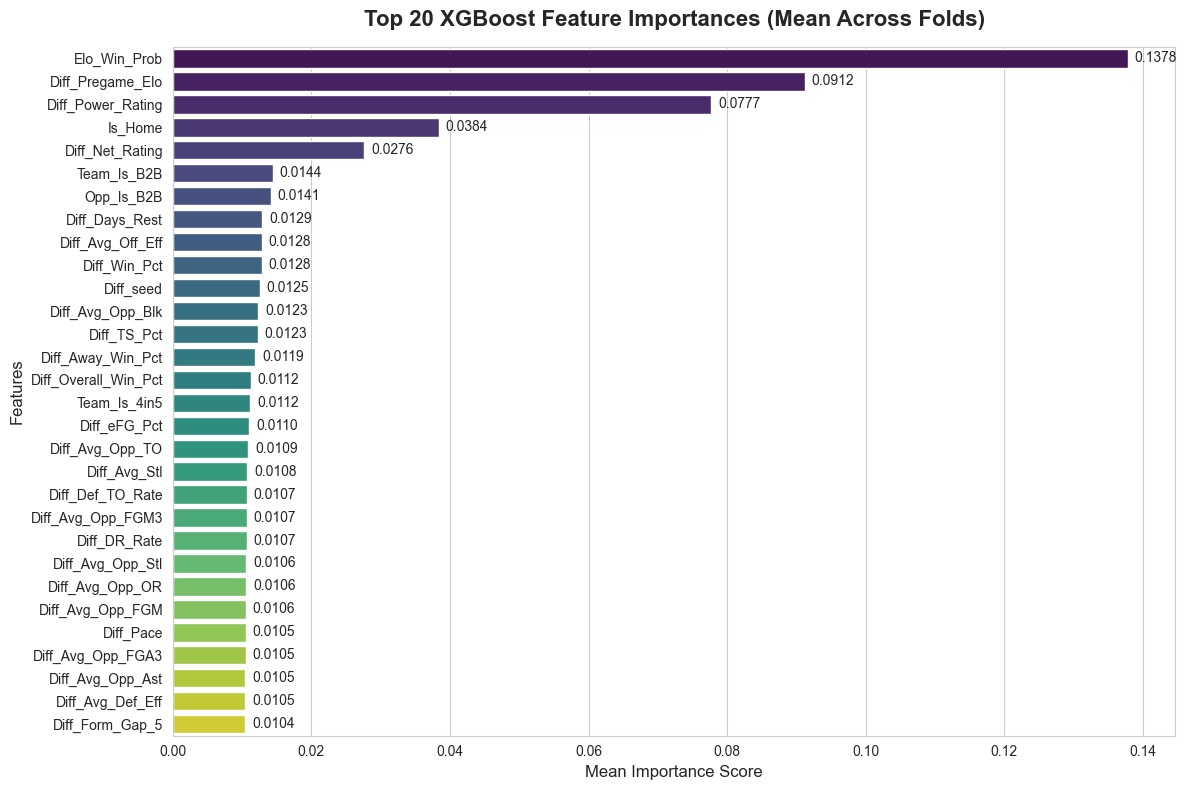

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Top features by mean importance across folds ----
fi = pd.DataFrame({f'fold_{i}': m.feature_importances_ for i, m in enumerate(fold_models)},
                  index=feature_cols)
fi['mean'] = fi.mean(axis=1)
fi = fi.sort_values('mean', ascending=False)

# ----------------------------------------------------
# VISUALIZATION: Top 20 Features
# ----------------------------------------------------
# Reset index so the feature names become a standard column we can plot
top_features = fi.head(30).reset_index()
top_features = top_features.rename(columns={'index': 'Feature'})

# Set up the plot size and style
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid") # Adds faint grid lines to make reading scores easier

# Create a horizontal bar chart
ax = sns.barplot(
    x='mean', 
    y='Feature', 
    data=top_features, 
    palette='viridis' # A clean, modern color gradient
)

# Formatting the chart
plt.title('Top 20 XGBoost Feature Importances (Mean Across Folds)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Mean Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Optional: Add the exact score numbers to the end of each bar
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.001, p.get_y() + p.get_height() / 2,
             f'{width:.4f}', 
             ha='left', va='center', fontsize=10)

# Adjust layout to fit long feature names and display
plt.tight_layout()
plt.show()

Dropped 720 games due to early-season NaNs.
--- EXACT LOGISTIC REGRESSION B VALUES ---
Diff_Avg_FTA                    -0.2078
Diff_Avg_Opp_FGM                -0.1791
Diff_Avg_Opp_Score              -0.1524
Diff_Avg_FGM3                   -0.1278
Diff_OR_Rate                    -0.1130
Diff_OR_Rate                    -0.1130
Diff_TO_Rate                    -0.1091
Diff_TO_Rate                    -0.1091
Team_Is_B2B                     -0.1079
Diff_Avg_Opp_DR                 -0.1019
Diff_seed                       -0.0878
Diff_Avg_Opp_Ast                -0.0871
Diff_Avg_Opp_FGA3               -0.0802
Diff_Avg_Score                  -0.0724
Diff_Avg_Opp_Blk                -0.0697
Diff_Avg_Opp_FTM                -0.0654
Diff_Win_Pct                    -0.0632
Diff_Overall_Win_Pct            -0.0632
Diff_Overall_Win_Pct            -0.0632
Diff_Def_FT_Rate                -0.0595
Diff_Def_FT_Rate                -0.0595
Diff_Last10_Win_Pct             -0.0447
Team_Altitude_Dis               -

C:\Users\Furag\AppData\Local\Temp\ipykernel_20720\508365190.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='B_Value', y='Feature', data=coef_df, palette=colors)
C:\Users\Furag\AppData\Local\Temp\ipykernel_20720\508365190.py:70: UserWarning: The palette list has more values (80) than needed (64), which may not be intended.
  ax = sns.barplot(x='B_Value', y='Feature', data=coef_df, palette=colors)


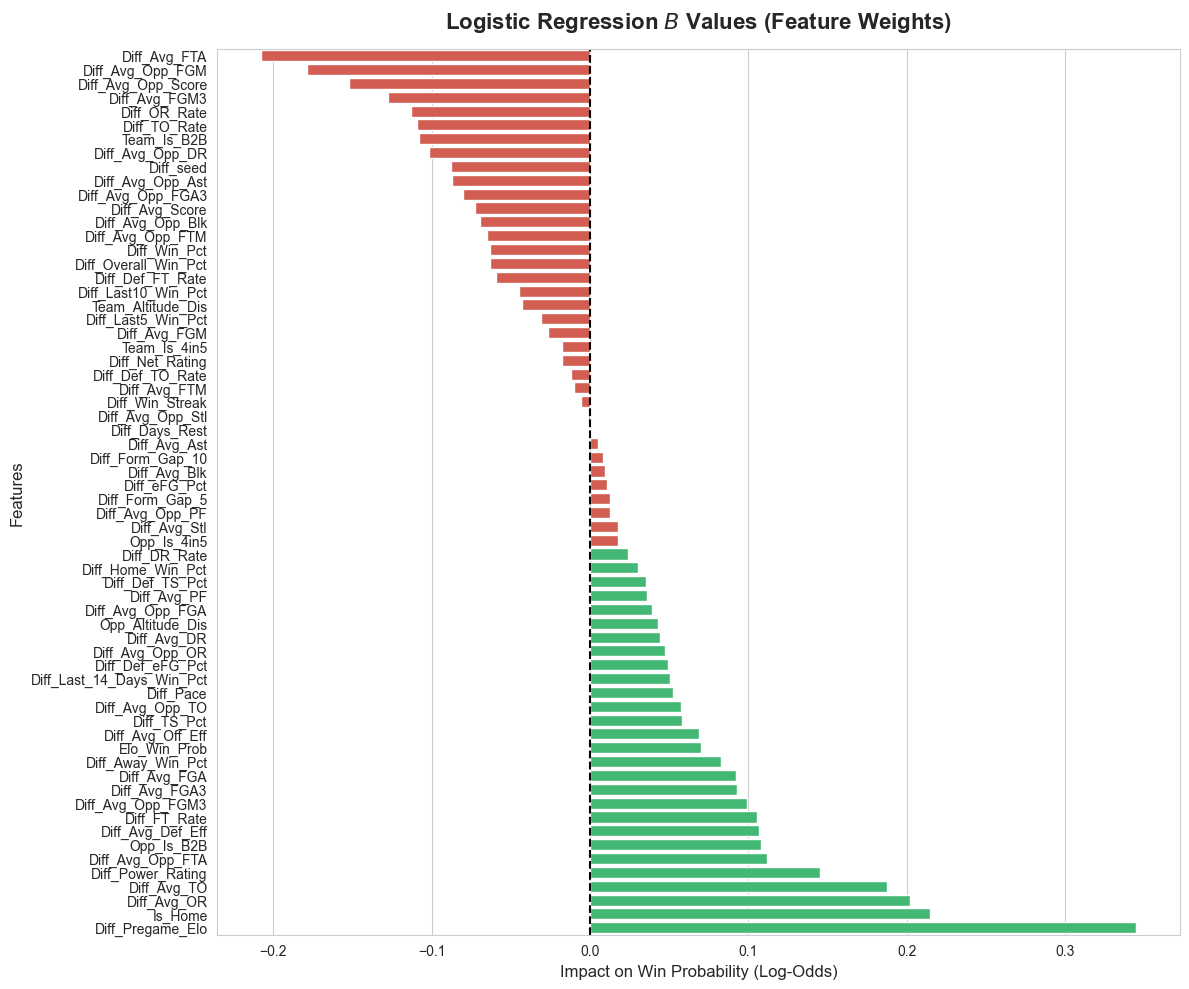

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. PREPARE THE ELITE WHITELIST
# ==========================================
# The Elite 27 Curated Features
elite_features = [
    'Is_Home', 'Team_Altitude_Dis', 'Opp_Altitude_Dis',
    'Team_Is_B2B', 'Opp_Is_B2B', 'Team_Is_4in5', 'Opp_Is_4in5', 'Diff_Days_Rest',
    'Elo_Win_Prob', 'Diff_Power_Rating', 'Diff_Net_Rating', 'Diff_Pace',
    'Diff_eFG_Pct', 'Diff_TS_Pct', 'Diff_OR_Rate', 'Diff_TO_Rate', 'Diff_FT_Rate',
    'Diff_Def_eFG_Pct', 'Diff_DR_Rate', 'Diff_Def_TO_Rate', 'Diff_Def_FT_Rate', 'Diff_Win_Streak', 
    'Diff_Form_Gap_10', 'Diff_Overall_Win_Pct'
]
safe_features = [c for c in df.columns if c.startswith('Diff_')] + elite_features
# Create a temporary combined dataframe to drop rows cleanly
temp_df = X.copy()
temp_df['Target_Win'] = y

# Drop any row that contains a NaN
clean_df = temp_df.dropna()

print(f"Dropped {len(X) - len(clean_df)} games due to early-season NaNs.")

# Re-split into clean X and y
X = clean_df.drop(columns=['Target_Win'])
y = clean_df['Target_Win']

# ==========================================
# 2. SCALE THE DATA (Crucial for Logistic Regression!)
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 3. TRAIN THE MODEL & EXTRACT B VALUES
# ==========================================
# C=0.1 applies a slight L2 penalty to prevent any single stat from going crazy
lr_model = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
lr_model.fit(X_scaled, y)

# Extract the B values (Coefficients)
b_values = lr_model.coef_[0]

# Create a clean DataFrame of the mathematical weights
coef_df = pd.DataFrame({
    'Feature': safe_features,
    'B_Value': b_values
}).sort_values(by='B_Value', ascending=True)

# Print the exact formulas
print("--- EXACT LOGISTIC REGRESSION B VALUES ---")
for index, row in coef_df.iterrows():
    print(f"{row['Feature']:<30s} {row['B_Value']:>8.4f}")

# ==========================================
# 4. VISUALIZE THE WEIGHTS (Positive vs Negative)
# ==========================================
plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

# Create a color palette: Green for positive weight, Red for negative weight
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in coef_df['B_Value']]

ax = sns.barplot(x='B_Value', y='Feature', data=coef_df, palette=colors)

plt.title('Logistic Regression $B$ Values (Feature Weights)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Impact on Win Probability (Log-Odds)', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Add a vertical line at 0 for easy reading
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.show()

In [18]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss

# ==========================================
# 1. PREPARE CLEAN, NaN-FREE DATA
# ==========================================
# We need 'Season' back in the dataframe so we can split it, 
# along with our elite features and the target.
temp_df = df[safe_features].copy()
temp_df['Target_Win'] = df['Target_Win']
temp_df['Season'] = df['Season'] 

# Drop the chaotic early-season games (NaNs)
clean_df = temp_df.dropna()
print(f"Running LR Validation on {len(clean_df)} clean games...\n")

# Define our pure features, targets, and our season splitter
X_clean = clean_df.drop(columns=['Target_Win', 'Season'])
y_clean = clean_df['Target_Win']
seasons = clean_df['Season']

# ==========================================
# 2. INITIALIZE ARRAYS
# ==========================================
oof_probs_lr = np.zeros(len(clean_df))
oof_preds_lr = np.zeros(len(clean_df))
unique_seasons = sorted(seasons.unique())

print("Starting Logistic Regression LOSO CV...\n")

# ==========================================
# 3. THE VALIDATION LOOP
# ==========================================
for val_season in unique_seasons:
    # --- Split Data ---
    train_idx = seasons != val_season
    val_idx   = seasons == val_season
    
    X_train, y_train = X_clean[train_idx], y_clean[train_idx]
    X_val, y_val     = X_clean[val_idx], y_clean[val_idx]
    
    # --- SCALING (Zero Leakage) ---
    # Fit the scaler ONLY on the training data! Then transform both.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)
    
    # --- Train Model ---
    lr_model = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
    lr_model.fit(X_train_scaled, y_train)
    
    # --- Predict ---
    val_probs = lr_model.predict_proba(X_val_scaled)[:, 1]
    val_preds = (val_probs >= 0.5).astype(int)
    
    # --- Store Results ---
    oof_probs_lr[val_idx] = val_probs
    oof_preds_lr[val_idx] = val_preds
    
    # --- Evaluate Fold ---
    season_acc = accuracy_score(y_val, val_preds)
    season_brier = brier_score_loss(y_val, val_probs)
    print(f"Season {val_season} | Acc: {season_acc:.4f} | Brier: {season_brier:.4f}")

# ==========================================
# 4. FINAL RESULTS
# ==========================================
lr_acc = accuracy_score(y_clean, oof_preds_lr)
lr_auc = roc_auc_score(y_clean, oof_probs_lr)
lr_brier = brier_score_loss(y_clean, oof_probs_lr)

print("\n" + "="*35)
print("LOGISTIC REGRESSION RESULTS")
print("="*35)
print(f"Overall Accuracy : {lr_acc:.4f}")
print(f"Overall ROC AUC  : {lr_auc:.4f}")
print(f"Overall Brier    : {lr_brier:.5f}")
print("="*35)

Running LR Validation on 22900 clean games...

Starting Logistic Regression LOSO CV...

Season 2016 | Acc: 0.6339 | Brier: 0.2229
Season 2017 | Acc: 0.6480 | Brier: 0.2165
Season 2018 | Acc: 0.6596 | Brier: 0.2120
Season 2019 | Acc: 0.6550 | Brier: 0.2170
Season 2020 | Acc: 0.6374 | Brier: 0.2236
Season 2021 | Acc: 0.6483 | Brier: 0.2202
Season 2022 | Acc: 0.6307 | Brier: 0.2257
Season 2023 | Acc: 0.6559 | Brier: 0.2112
Season 2024 | Acc: 0.6650 | Brier: 0.2086
Season 2025 | Acc: 0.6871 | Brier: 0.2042

LOGISTIC REGRESSION RESULTS
Overall Accuracy : 0.6522
Overall ROC AUC  : 0.7113
Overall Brier    : 0.21609
